# Machine Learning Assignment
Heart Disease Prediction using Classification


In [1]:
#  for data handling
import pandas as pd
import numpy as np

# for visualization
import matplotlib.pyplot as plt
import seaborn as sns

#  for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# Load the Heart Disease dataset
df_ml = pd.read_csv("heart.csv")

# Display first 5 rows
df_ml.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df_ml.shape

(1025, 14)

In [4]:
df_ml.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [5]:
# Dataset information
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
# Check for missing values
df_ml.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
# Separate input features (X) and target variable (y)
X = df_ml.drop('target', axis=1)
y = df_ml['target']

Train–Test Split

In [8]:
# Split the dataset into training and testing sets (80:20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
# max_iter is increased to ensure the model converges
model = LogisticRegression(max_iter=1000)

In [10]:
# Train the model using training data
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [11]:
# Predict target values for test data
y_pred = model.predict(X_test)

In [12]:
# Calculate accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7951219512195122

In [13]:
# Display precision, recall, f1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205



In [14]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm


array([[73, 29],
       [13, 90]])

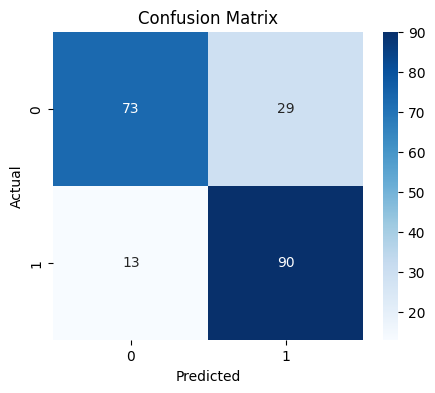

In [15]:
# Visualize confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [16]:
# Display feature importance using model coefficients
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

feature_importance

,Feature,Coefficient
2,cp,0.847057
10,slope,0.535876
6,restecg,0.262391
7,thalach,0.028880
0,age,0.000642
4,chol,-0.008867
3,trestbps,-0.018159
5,fbs,-0.164529
9,oldpeak,-0.679894
11,ca,-0.814054


Random Forest Classifier

In [17]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

In [18]:
# n_estimators = number of trees in the forest
# random_state ensures reproducibility
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [19]:
# Train the Random Forest model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [20]:
# Predict on test data
rf_y_pred = rf_model.predict(X_test)

In [21]:
# Calculate accuracy of Random Forest model
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_accuracy


0.9853658536585366

In [22]:
# Display classification report
print(classification_report(y_test, rf_y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [23]:
# Generate confusion matrix
rf_cm = confusion_matrix(y_test, rf_y_pred)
rf_cm

array([[102,   0],
       [  3, 100]])

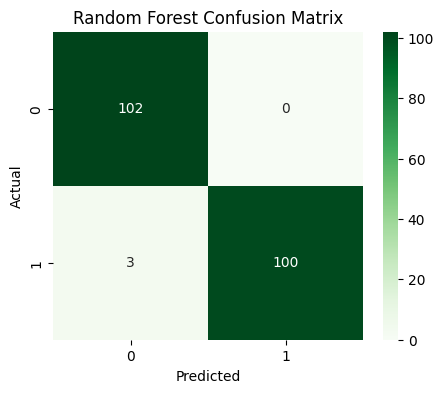

In [24]:
# Visualize Random Forest confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [25]:
# Extract feature importance from Random Forest
rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

rf_feature_importance

,Feature,Importance
2,cp,0.135072
11,ca,0.127327
7,thalach,0.122169
9,oldpeak,0.121905
12,thal,0.110518
0,age,0.077908
4,chol,0.074822
3,trestbps,0.071171
8,exang,0.057594
10,slope,0.045782


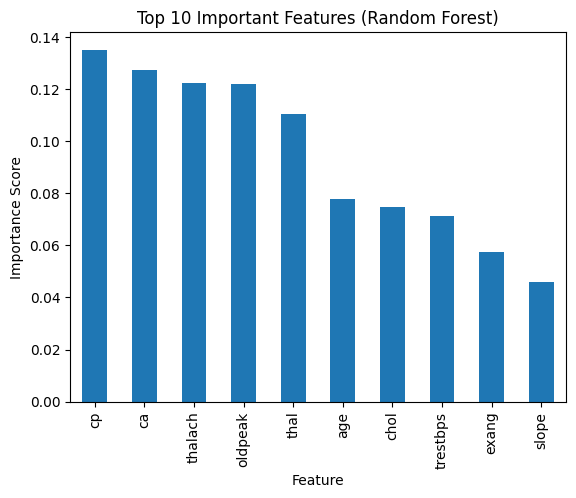

In [26]:
# Plot feature importance
rf_feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    legend=False
)

plt.title("Top 10 Important Features (Random Forest)")
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.show()


In [27]:
# Compare model accuracies
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, rf_accuracy]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.795122
1,Random Forest,0.985366


## Conclusion

In addition to Logistic Regression, a Random Forest Classifier was implemented to enhance prediction performance. The Random Forest model achieved higher accuracy and provided feature importance analysis, demonstrating its effectiveness in handling complex patterns. This comparison highlights the benefit of ensemble learning techniques in supervised machine learning.
The results demonstrate that supervised machine learning techniques can effectively classify health-related data.